# 1. Introduction
#### Modélisation Prophet

**Objectif**

Cette étape consiste à utiliser le modèle Prophet afin de prévoir les futures commandes de carburant des stations-service.

Le modèle Prophet permet de prendre en compte :
- les tendances ;
- les variations saisonnières ;
- les changements de comportement dans le temps.

Cette approche vise à évaluer les performances d’un modèle moderne de forecasting sur les données de commandes pétrolières.

In [ ]:
!pip install prophet

## 2. Importation des Bibliothèques

In [28]:
# IMPORTATION DES BIBLIOTHEQUES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 3. Chargement des commandes propres

In [30]:
# CHARGEMENT DU DATASET

df = pd.read_excel("../data/propre/commandes_propres.xlsx")

print(df.shape)

display(df.head())

(34150, 13)


,Date comptabilisation,N° article,N° origine,N° contact origine,Quantité facturée,Code Produit,Type document,NOM CLIENT,Nom sous compte,TYPE,STATUT,Code Station,GROUPE TYPE
0,2020-01-13,A0001,C1234,CC2616,5000,PROD-BLANC,Expédition vente,GIBLAND COMPAGNY,STATION ATTAKE,CODO,Fonctionnelle,ST0049,STATION
1,2020-01-13,A0002,C1234,CC2616,4000,PROD-BLANC,Expédition vente,GIBLAND COMPAGNY,STATION ATTAKE,CODO,Fonctionnelle,ST0049,STATION
2,2020-01-13,A0001,C1249,CC2650,1000,PROD-BLANC,Expédition vente,TONI ET FILS,STATION NDALI,DODO,Fonctionnelle,ST0092,STATION
3,2020-01-13,A0002,C1249,CC2650,16000,PROD-BLANC,Expédition vente,TONI ET FILS,STATION NDALI,DODO,Fonctionnelle,ST0092,STATION
4,2020-01-13,A0001,C1233,CC2614,5000,PROD-BLANC,Expédition vente,AYODELE BUSINESS,STATION OUIDAH,CODO,Fonctionnelle,ST0016,STATION


# 4. Conversion des dates
ARIMA travaille uniquement avec des séries temporelles ordonnées.

In [31]:
# CONVERSION DATES

df["Date comptabilisation"] = pd.to_datetime(
    df["Date comptabilisation"]
)

## 5. Sélection d’une station et d’un produit
ARIMA ne gère pas naturellement plusieurs stations simultanément, donc une série = une station + un produit.

In [89]:
# FILTRAGE STATION + PRODUIT


station = "ST0001"
produit = "A0001"

df_station = df[
    (df["Code Station"] == station) &
    (df["N° article"] == produit)
].copy()

print(df_station.shape)

(323, 13)


## 6. Agrégation journalière

In [91]:
# AGREGATION JOURNALIERE

df_prophet = (
    df_station
    .groupby("Date comptabilisation")
    ["Quantité facturée"]
    .sum()
    .reset_index()
)

print(type(df_prophet))

<class 'pandas.core.frame.DataFrame'>


In [93]:
# =========================================================
# FORMAT PROPHET
# =========================================================

df_prophet.columns = ["ds", "y"]

display(df_prophet.head())

,ds,y
0,2022-09-27,20000
1,2022-10-17,8000
2,2022-10-24,6000
3,2022-10-25,10000
4,2022-11-03,15000


timmeserise
DECOMPSE LA SERIE POUR VOIR (TANDANCES, SAISONALITE ET BRUT)
ENLEVER TANDANCES ET SAISONALITE APRES ESTIMATION PUIS MODELISER LE BRUIT
PACF ACF TEST AUTOCOLERATION ET TEST DE STASIONNALITE, DETERMINON LES PARAMETRES


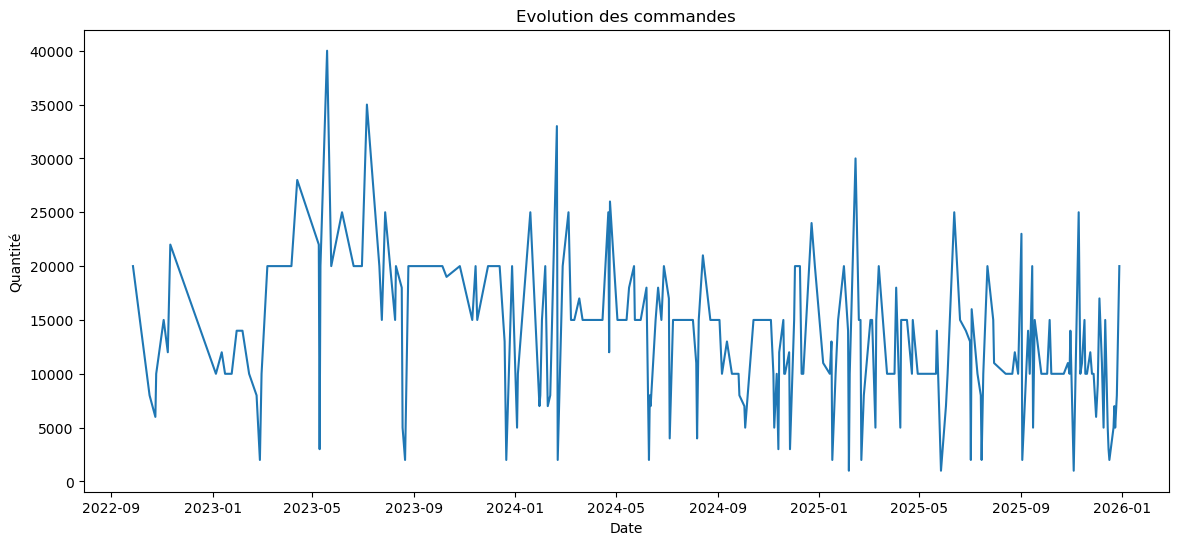

In [95]:
# VISUALISATION

plt.figure(figsize=(14,6))

plt.plot(
    df_prophet["ds"],
    df_prophet["y"]
)

plt.title("Evolution des commandes")

plt.xlabel("Date")
plt.ylabel("Quantité")

plt.show()

## 5. Séparation Train/Test
Mon problème étant temporel, alors il faut :entraîner sur le passé ettester sur le futur.
Sinon : fuite de données et faux résultats.

In [97]:
# TRAIN / TEST

train_size = int(len(df_prophet) * 0.8)

train = df_prophet[:train_size]
test = df_prophet[train_size:]

# 6. Construction du modèle Prophet
Explication importante
yearly_seasonality capture :tendances annuelles.
weekly_seasonality
Très pertinent ici :comportement semaine/weekend.


In [99]:
# MODELE PROPHET

model = Prophet(

    yearly_seasonality=True,

    weekly_seasonality=True,

    daily_seasonality=False
)

In [101]:
# ENTRAINEMENT


model.fit(train)

17:13:46 - cmdstanpy - INFO - Chain [1] start processing
17:13:47 - cmdstanpy - INFO - Chain [1] done processing


In [103]:
# FUTUR: Créer les futures dates à prédire.

future = model.make_future_dataframe(
    periods=len(test)
)

## 7. Prédictions
Le modèle tente ici d'estimer les futures commandes

In [105]:
# PREDICTIONS
forecast = model.predict(future)

display(
    forecast[
        [
            "ds",
            "yhat"
        ]
    ].tail()
)

,ds,yhat
232,2025-09-05,12139.190538
233,2025-09-06,11124.180444
234,2025-09-07,11258.860207
235,2025-09-08,8259.742724
236,2025-09-09,12071.654529


In [107]:
# PREDICTIONS TEST
# =========================================================

predictions = forecast["yhat"][-len(test):].values

## 8. Évaluation des performances

### 8.1 MAE
Le MAE mesure l’erreur moyenne absolue.

In [109]:
# MAE

mae = mean_absolute_error(
    test["y"],
    predictions
)

print("MAE :", mae)

MAE : 4279.327114256942


### 8.2 RMSE

Pénalise fortement les grosses erreurs.

In [111]:
# RMSE

rmse = np.sqrt(
    mean_squared_error(
        test["y"],
        predictions
    )
)

print("RMSE :", rmse)

RMSE : 5635.676720797823


### 8.3 R2 SCORE

Mesure la qualité globale du modèle.

In [113]:
# R2 SCORE

r2 = r2_score(
    test["y"],
    predictions
)

print("R² :", r2)

R² : -0.2625649725063084


## 9. Comparaison Réel vs Prédit

In [115]:
# REEL VS PREDIT

comparaison = pd.DataFrame({
    "Réel": test["y"].values,
    "Prédit": predictions
})

display(comparaison.head(20))

,Réel,Prédit
0,15000,12968.451378
1,11000,14539.320584
2,10000,13543.930922
3,10000,13706.192848
4,12000,10739.614184
5,10000,14585.636003
6,23000,10054.605322
7,2000,13801.340653
8,14000,15118.258708
9,10000,13839.317325


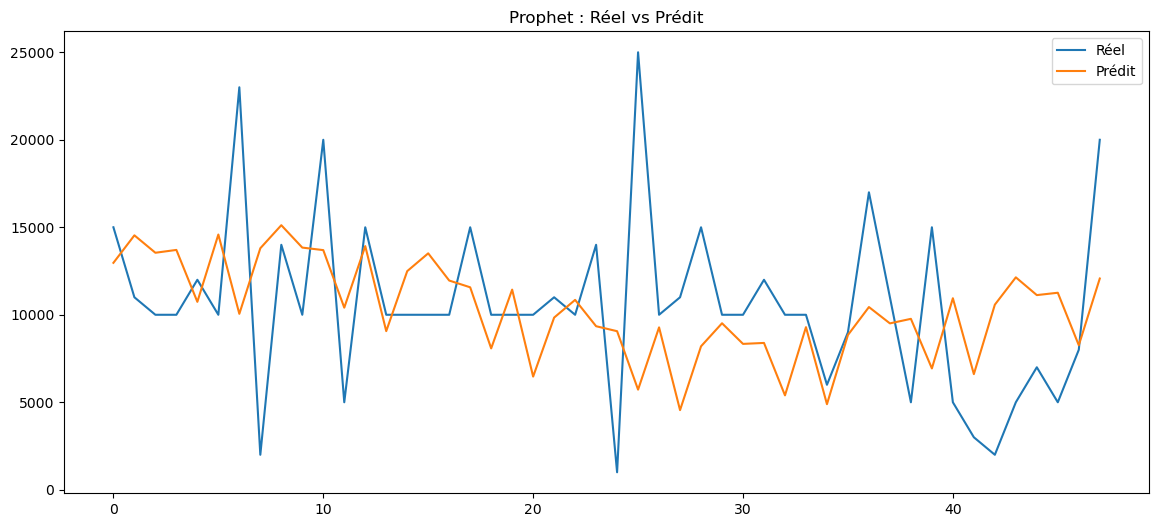

In [117]:
# GRAPHIQUE

plt.figure(figsize=(14,6))

plt.plot(
    test["y"].values,
    label="Réel"
)

plt.plot(
    predictions,
    label="Prédit"
)

plt.legend()

plt.title("Prophet : Réel vs Prédit")

plt.show()

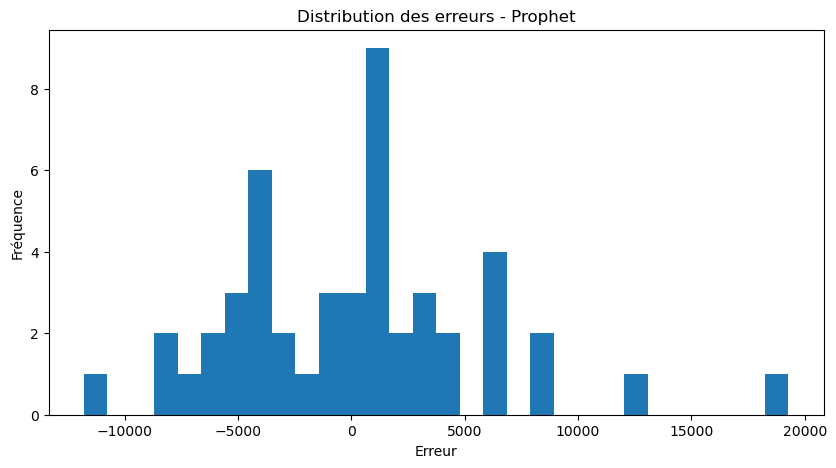

In [119]:
# Distribution des erreurs

errors = test["y"].values - predictions

plt.figure(figsize=(10,5))

plt.hist(errors, bins=30)

plt.title("Distribution des erreurs - Prophet")

plt.xlabel("Erreur")
plt.ylabel("Fréquence")

plt.show()

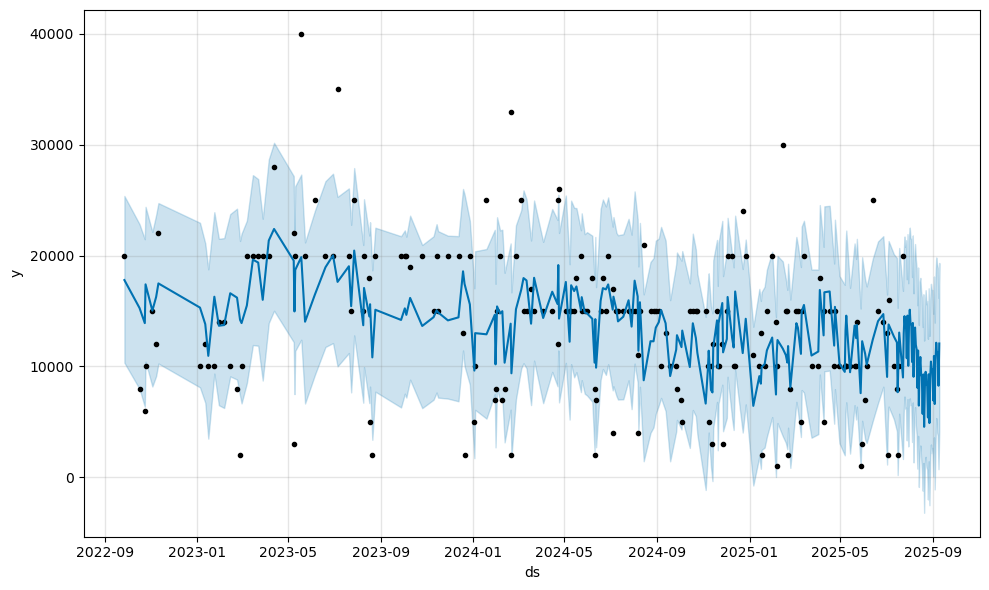

In [121]:
# FORECAST GLOBAL
# =========================================================

fig = model.plot(forecast)

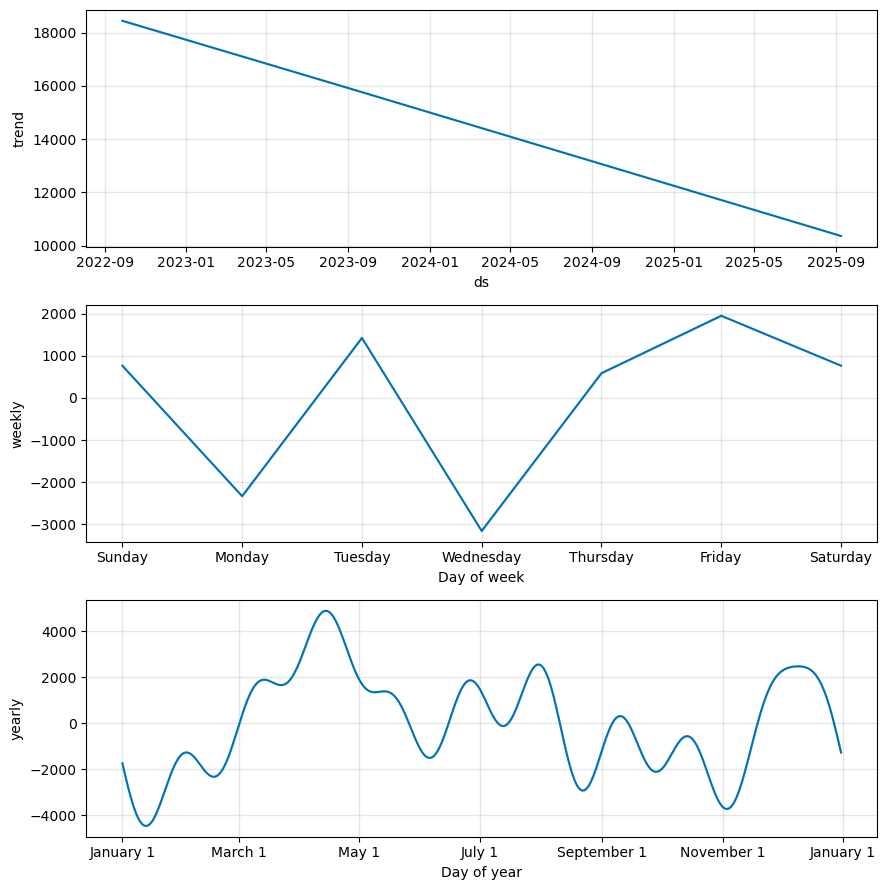

In [123]:
# COMPOSANTES
# =========================================================

fig2 = model.plot_components(
    forecast
)

In [125]:
# COMPARAISON FINALE

comparaison = pd.DataFrame({
    "Modele": [
        "Random Forest",
        "XGBoost",
        "ARIMA",
        "SARIMA",
        "Prophet"
    ],

    "MAE": [
        2702.52,
        2756.39,
        3690.72,
        3778.84,
        mae
    ],

    "RMSE": [
        3677.12,
        3808.61,
        5032.55,
        5243.43,
        rmse
    ],

    "R2": [
        0.626,
        0.598,
        -0.006,
        -0.093,
        r2
    ]
})

display(comparaison)

,Modele,MAE,RMSE,R2
0,Random Forest,2702.520000,3677.120000,0.626000
1,XGBoost,2756.390000,3808.610000,0.598000
2,ARIMA,3690.720000,5032.550000,-0.006000
3,SARIMA,3778.840000,5243.430000,-0.093000
4,Prophet,4279.327114,5635.676721,-0.262565


## 10. Sauvegarde du modèle

Le modèle pourra être :réutilisé, intégré dans Streamlit, déployé.

In [128]:
# SAUVEGARDE

import joblib

joblib.dump(
    model,
    "prophet_model.pkl"
)

print("Modèle sauvegardé.")

Modèle sauvegardé.


# Conclusion générale

Les expérimentations réalisées montrent que les modèles de Machine Learning offrent les meilleures performances pour la prévision des commandes de carburant des stations-service.

Le modèle Random Forest obtient les meilleurs résultats avec :
- le MAE le plus faible ;
- le RMSE le plus faible ;
- ainsi que le meilleur coefficient R².

Ces performances indiquent que les approches de Machine Learning sont capables de mieux capturer les comportements complexes et non linéaires présents dans les données étudiées.

Le modèle XGBoost présente également de très bonnes performances, confirmant la pertinence des méthodes de boosting pour ce type de problématique.

À l’inverse, les modèles statistiques classiques tels que ARIMA et SARIMA obtiennent des performances nettement inférieures. Ces résultats montrent que les séries temporelles des commandes de carburant présentent :
- une forte volatilité ;
- des variations irrégulières ;
- une faible stabilité saisonnière ;
- ainsi qu’une dynamique difficilement modélisable par des approches linéaires classiques.

Le modèle Prophet, malgré sa capacité à gérer automatiquement les tendances et saisonnalités, présente également des performances limitées dans cette étude. Cela suggère que les comportements de commande sont fortement influencés par des facteurs métier externes non directement capturés par les modèles temporels traditionnels.

Cette étude met ainsi en évidence l’importance :
- du feature engineering ;
- des variables explicatives métier ;
- ainsi que des approches de Machine Learning dans la prévision des commandes pétrolières.

Les résultats obtenus démontrent que les modèles basés sur l’apprentissage automatique constituent une solution plus adaptée pour accompagner les décisions logistiques et opérationnelles dans le secteur de la distribution de carburant.